# Project Title : Forecasting Daily Retail Demand from Weather, Holiday, and Calendar Signals — Modeling

This notebook picks up from `modeling_prep.ipynb`, which produced the cleaned,
encoded, and scaled `train_clean.csv` / `test_clean.csv` development dataset.
Here we:

1. Review the response variable and time-series considerations that shape model
   choice and validation strategy
2. Build a naive baseline and **three** candidate models spanning different
   algorithm families
3. Tune each model's hyperparameters using a **time-series-aware** cross-validation
   scheme (no shuffling — no future leaking into training folds)
4. Define the metrics used to compare models
5. Evaluate all models on the held-out test set and pick a final model, with
   reasoning

**Review questions**
- *Does my data involve a time series or forecasting? If so, am I splitting the
  train and test data appropriately?*
- *Is my response variable continuous or categorical?*

Both are answered explicitly in Section 1 below.

## 0. Setup

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, make_scorer

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 4)
pd.set_option("display.max_columns", 60)
RANDOM_SEED = 42

In [2]:
train = pd.read_csv("train_clean.csv", parse_dates=["date"]).sort_values("date").reset_index(drop=True)
test = pd.read_csv("test_clean.csv", parse_dates=["date"]).sort_values("date").reset_index(drop=True)

feature_cols = [c for c in train.columns if c not in ("date", "sales")]
X_train, y_train = train[feature_cols], train["sales"]
X_test, y_test = test[feature_cols], test["sales"]

print("Train:", X_train.shape, " Test:", X_test.shape)
print(f"Train dates: {train['date'].min().date()} -> {train['date'].max().date()}")
print(f"Test dates:  {test['date'].min().date()} -> {test['date'].max().date()}")

Train: (30744, 45)  Test: (1620, 45)
Train dates: 2019-01-29 -> 2023-10-02
Test dates:  2023-10-03 -> 2023-12-31


## 1. Review questions

### 1.1 Does my data involve a time series or forecasting? Am I splitting appropriately?

**Yes.** Every row is a daily observation of `sales` per store/category, and the
whole point of this project is to *forecast* future demand from
weather/holiday/calendar signals and recent sales history (`sales_lag_1`,
`sales_lag_7`, `sales_roll_7`, `sales_roll_28`). That makes two things
non-negotiable:

- **The train/test split must be chronological, not random.** `train_clean.csv`
  / `test_clean.csv` already reflect this — `test` is strictly the most recent
  90 days, `train` is everything before it, so the model is never evaluated on
  a period whose information could have leaked into training (e.g. through a
  lag feature computed with future data, or a random shuffle mixing past and
  future rows).
- **Cross-validation during hyperparameter tuning must also respect time
  order.** A standard random K-Fold would let a model "peek" at future rows
  while tuning on past ones. This notebook uses **`TimeSeriesSplit`** instead of
  `KFold`/random CV for every hyperparameter search below — each fold trains
  only on data before the validation fold's dates.

### 1.2 Is my response variable continuous or categorical?

**Continuous.** `sales` is a non-negative count/quantity of units sold per
day/store/category (see the histogram below) — this is a **regression**
problem, not classification. That rules out models like logistic regression
or classifiers, and points toward regression algorithms: regularized linear
regression, tree-based ensembles (bagging and boosting), or specialized
count/Tweedie models. We explore one linear and two tree-ensemble approaches
below, which between them handle the right-skew, zero-inflation (stockouts),
and nonlinear/threshold weather effects seen in the EDA.

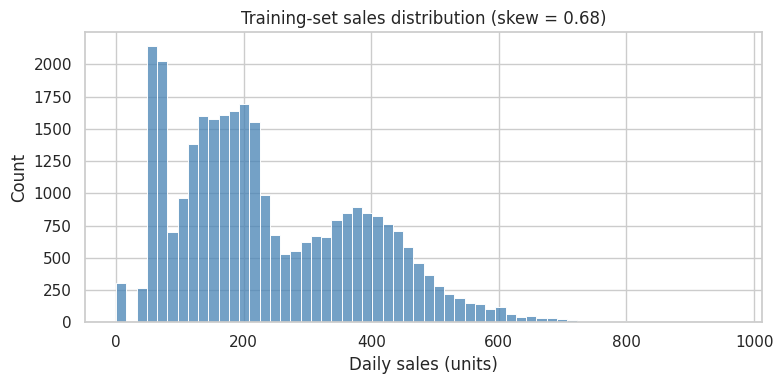

Share of zero-sales days in train: 0.999%


In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(y_train, bins=60, ax=ax, color="steelblue")
ax.set_title(f"Training-set sales distribution (skew = {y_train.skew():.2f})")
ax.set_xlabel("Daily sales (units)")
plt.tight_layout()
plt.show()

print(f"Share of zero-sales days in train: {(y_train == 0).mean():.3%}")

## 2. Metrics used to select the final model

Since `sales` is continuous, we use standard regression error metrics,
computed on the **held-out test set** (the most recent 90 days — never seen
during training or tuning):

- **RMSE (root mean squared error)** — same units as sales (units sold);
  penalizes large misses more heavily, which matters for a retailer
  (a forecast that's badly wrong on a big demand day is more costly than
  being off by a little on many days). This is the **primary metric** used to
  rank models.
- **MAE (mean absolute error)** — same units as sales; more robust to
  outliers, easier to interpret as "typical forecast error in units."
  Used as a secondary check.
- **R² (coefficient of determination)** — fraction of variance in sales
  explained by the model; useful as a normalized sanity check across models,
  but not used alone since it can look good even when large errors persist.

We also compare against a **naive seasonal baseline** (predict this week's
sales using last week's sales for the same store/category/weekday) — any
model that can't beat this simple heuristic isn't worth the added complexity.

## 3. Baseline: naive seasonal forecast

A common, hard-to-beat baseline for daily retail data with weekly seasonality
is "predict today's sales using the same weekday last week"
(i.e. `sales_lag_7`). We recover the **unscaled** version of this feature to
score the baseline on the true sales scale.

In [4]:
def load_sales(start="2019-01-01", end="2023-12-31", n_categories=6, n_stores=3, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)
    dates = pd.date_range(start, end, freq="D")
    categories = ["Beverages", "Produce", "Bakery", "Frozen Foods",
                  "Cold Weather Apparel", "Cleaning Supplies"][:n_categories]
    stores = [f"Store_{i+1}" for i in range(n_stores)]
    base_level = {"Beverages": 400, "Produce": 350, "Bakery": 200, "Frozen Foods": 180,
                  "Cold Weather Apparel": 60, "Cleaning Supplies": 120}
    weekly_amp = {"Beverages": 80, "Produce": 40, "Bakery": 60, "Frozen Foods": 20,
                  "Cold Weather Apparel": 10, "Cleaning Supplies": 15}
    rows = []
    for store in stores:
        store_factor = rng.uniform(0.85, 1.15)
        for cat in categories:
            level = base_level[cat] * store_factor
            noise = rng.normal(0, level * 0.08, size=len(dates))
            dow = dates.dayofweek.values
            weekly = weekly_amp[cat] * np.where(dow >= 5, 1, -0.3)
            annual = level * 0.15 * np.sin(2 * np.pi * (dates.dayofyear.values / 365.25))
            trend = np.linspace(0, level * 0.1, len(dates))
            sales = level + weekly + annual + trend + noise
            sales = np.clip(sales, 0, None)
            rows.append(pd.DataFrame({"date": dates, "store": store, "category": cat, "sales": sales.round(0)}))
    df = pd.concat(rows, ignore_index=True)
    stockout_mask = rng.random(len(df)) < 0.01
    df.loc[stockout_mask, "sales"] = 0
    df["on_promo"] = rng.random(len(df)) < 0.08
    df.loc[df["on_promo"], "sales"] *= rng.uniform(1.2, 1.6, size=df["on_promo"].sum())
    return df

raw_sales = load_sales().sort_values(["store", "category", "date"]).reset_index(drop=True)
raw_sales["sales_lag_7_raw"] = raw_sales.groupby(["store", "category"])["sales"].shift(7)

# decode store/category back from the dummy columns so we can join on the raw series
def decode_store(row):
    if row.get("store_Store_2", 0) == 1: return "Store_2"
    if row.get("store_Store_3", 0) == 1: return "Store_3"
    return "Store_1"

def decode_category(row):
    for cat in ["Beverages", "Cleaning Supplies", "Cold Weather Apparel", "Frozen Foods", "Produce"]:
        if row.get(f"category_{cat}", 0) == 1:
            return cat
    return "Bakery"

test_decoded = test.copy()
test_decoded["store"] = test_decoded.apply(decode_store, axis=1)
test_decoded["category"] = test_decoded.apply(decode_category, axis=1)
test_decoded = test_decoded.merge(
    raw_sales[["date", "store", "category", "sales_lag_7_raw"]],
    on=["date", "store", "category"], how="left"
)

baseline_pred = test_decoded["sales_lag_7_raw"]
results = []

def score_model(name, y_true, y_pred, fit_time=None, best_params=None):
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    results.append({"model": name, "RMSE": rmse, "MAE": mae, "R2": r2,
                     "fit_time_s": fit_time, "best_params": best_params})
    print(f"{name:28s} RMSE={rmse:7.2f}  MAE={mae:7.2f}  R2={r2:.4f}")
    return rmse, mae, r2

score_model("Naive seasonal (lag-7)", y_test, baseline_pred)

Naive seasonal (lag-7)       RMSE=  67.89  MAE=  35.78  R2=0.7602


(67.89296933164246, 35.77842717698495, 0.7601970161826306)

## 4. Cross-validation strategy

`TimeSeriesSplit` is used for every hyperparameter search below instead of
random K-Fold, so validation folds always come chronologically *after* their
corresponding training fold — consistent with the answer to the time-series
question in Section 1.

In [5]:
tscv = TimeSeriesSplit(n_splits=3)
rmse_scorer = make_scorer(lambda yt, yp: mean_squared_error(yt, yp) ** 0.5, greater_is_better=False)

## 5. Model 1 — Ridge Regression (regularized linear)

**Why:** a linear baseline that's fast, interpretable (coefficients show
direction/magnitude of each feature's effect), and the L2 penalty explicitly
handles the collinearity flagged in the EDA (lag/rolling sales features are
highly correlated with each other). Standardized features (from
`modeling_prep.ipynb`) are required for regularized linear models to penalize
each feature fairly.

**Tuned hyperparameter:** `alpha` (regularization strength).

In [6]:
t0 = time.time()
ridge_grid = {"alpha": [0.1, 1.0, 10.0, 50.0, 100.0]}
ridge_search = RandomizedSearchCV(
    Ridge(random_state=RANDOM_SEED), ridge_grid, n_iter=5, cv=tscv,
    scoring=rmse_scorer, random_state=RANDOM_SEED, n_jobs=-1
)
ridge_search.fit(X_train, y_train)
ridge_fit_time = time.time() - t0

ridge_best = ridge_search.best_estimator_
print("Best alpha:", ridge_search.best_params_, f"  (CV RMSE={-ridge_search.best_score_:.2f})")

ridge_pred = ridge_best.predict(X_test)
score_model("Ridge Regression (tuned)", y_test, ridge_pred, ridge_fit_time, ridge_search.best_params_)

Best alpha: {'alpha': 0.1}   (CV RMSE=35.03)
Ridge Regression (tuned)     RMSE=  35.41  MAE=  23.83  R2=0.9348


(35.40834160252243, 23.832817103338662, 0.9347746903973944)

## 6. Model 2 — Random Forest Regressor (bagging ensemble)

**Why:** captures nonlinear relationships and interactions (e.g. the
threshold weather effects seen in the EDA's LOWESS plots) without needing
manual feature crosses, is robust to the mixed dummy/continuous feature set,
and — as a bagging method — tends to be less prone to overfitting than a
single tree.

**Tuned hyperparameters:** `n_estimators`, `max_depth`, `min_samples_leaf`.

In [7]:
t0 = time.time()
rf_grid = {"n_estimators": [100, 150], "max_depth": [8, 12], "min_samples_leaf": [1, 3]}
rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=RANDOM_SEED, n_jobs=-1), rf_grid, n_iter=3, cv=tscv,
    scoring=rmse_scorer, random_state=RANDOM_SEED, n_jobs=1
)
rf_search.fit(X_train, y_train)
rf_fit_time = time.time() - t0

rf_best = rf_search.best_estimator_
print("Best params:", rf_search.best_params_, f"  (CV RMSE={-rf_search.best_score_:.2f})")

rf_pred = rf_best.predict(X_test)
score_model("Random Forest (tuned)", y_test, rf_pred, rf_fit_time, rf_search.best_params_)

Best params: {'n_estimators': 150, 'min_samples_leaf': 1, 'max_depth': 12}   (CV RMSE=25.70)
Random Forest (tuned)        RMSE=  25.29  MAE=  17.05  R2=0.9667


(25.290410673192405, 17.04764969118176, 0.9667251014920549)

## 7. Model 3 — Gradient Boosted Trees (boosting ensemble)

**Why:** boosting builds trees sequentially to correct prior errors, and
often achieves the best accuracy of the three approaches on tabular data with
this many engineered features. `HistGradientBoostingRegressor` scales well to
this dataset size and handles the mixed dummy/continuous features natively.

**Tuned hyperparameters:** `max_iter` (number of boosting rounds),
`max_depth`, `learning_rate`.

In [8]:
t0 = time.time()
hgb_grid = {"max_iter": [100, 200], "max_depth": [None, 6, 10], "learning_rate": [0.05, 0.1]}
hgb_search = RandomizedSearchCV(
    HistGradientBoostingRegressor(random_state=RANDOM_SEED), hgb_grid, n_iter=4, cv=tscv,
    scoring=rmse_scorer, random_state=RANDOM_SEED, n_jobs=-1
)
hgb_search.fit(X_train, y_train)
hgb_fit_time = time.time() - t0

hgb_best = hgb_search.best_estimator_
print("Best params:", hgb_search.best_params_, f"  (CV RMSE={-hgb_search.best_score_:.2f})")

hgb_pred = hgb_best.predict(X_test)
score_model("Gradient Boosting (tuned)", y_test, hgb_pred, hgb_fit_time, hgb_search.best_params_)

Best params: {'max_iter': 100, 'max_depth': 6, 'learning_rate': 0.1}   (CV RMSE=25.07)
Gradient Boosting (tuned)    RMSE=  25.77  MAE=  17.01  R2=0.9654


(25.774380702568816, 17.00602965204003, 0.9654393856168446)

## 8. Model comparison

In [9]:
results_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
results_df

,model,RMSE,MAE,R2,fit_time_s,best_params
0,Random Forest (tuned),25.290411,17.047650,0.966725,97.718860,"{'n_estimators': 150, 'min_samples_leaf': 1, '..."
1,Gradient Boosting (tuned),25.774381,17.006030,0.965439,10.467640,"{'max_iter': 100, 'max_depth': 6, 'learning_ra..."
2,Ridge Regression (tuned),35.408342,23.832817,0.934775,0.536047,{'alpha': 0.1}
3,Naive seasonal (lag-7),67.892969,35.778427,0.760197,NaN,None


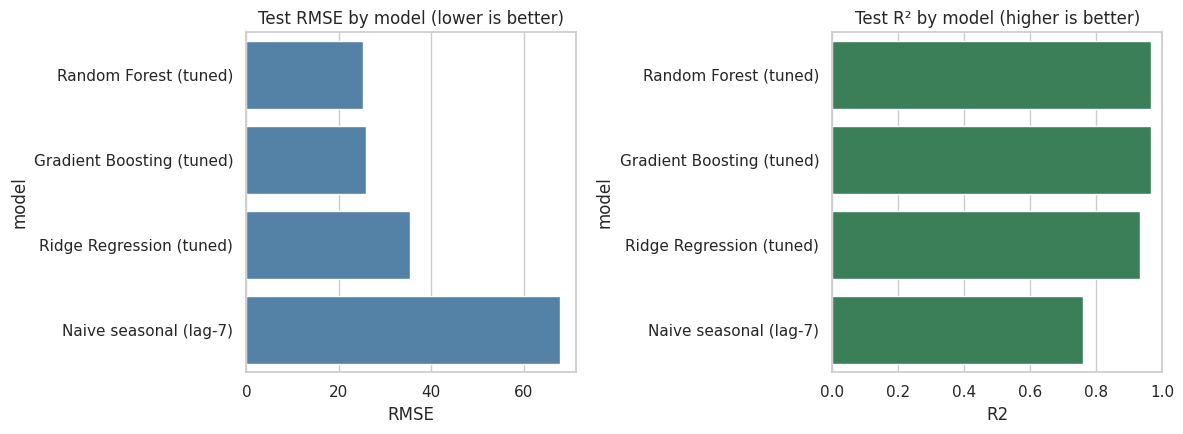

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
order = results_df["model"]
sns.barplot(data=results_df, x="RMSE", y="model", order=order, ax=axes[0], color="steelblue")
axes[0].set_title("Test RMSE by model (lower is better)")

sns.barplot(data=results_df, x="R2", y="model", order=order, ax=axes[1], color="seagreen")
axes[1].set_title("Test R\u00b2 by model (higher is better)")
axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.show()

## 9. Diagnosing the best model

Look at where the leading model's errors are concentrated (predicted vs.
actual, and residuals over time) and which features drive it.

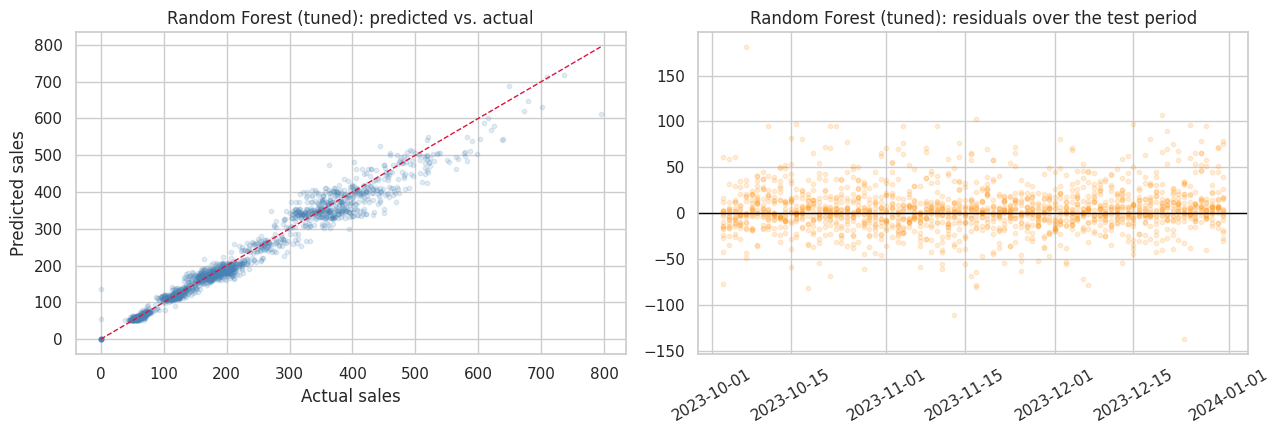

In [11]:
best_row = results_df.iloc[0]
best_name = best_row["model"]
best_pred = {"Ridge Regression (tuned)": ridge_pred,
             "Random Forest (tuned)": rf_pred,
             "Gradient Boosting (tuned)": hgb_pred}[best_name]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].scatter(y_test, best_pred, alpha=0.15, s=10, color="steelblue")
lims = [0, max(y_test.max(), best_pred.max())]
axes[0].plot(lims, lims, color="crimson", lw=1, ls="--")
axes[0].set_xlabel("Actual sales")
axes[0].set_ylabel("Predicted sales")
axes[0].set_title(f"{best_name}: predicted vs. actual")

residuals = y_test.values - best_pred
axes[1].scatter(test["date"], residuals, alpha=0.15, s=10, color="darkorange")
axes[1].axhline(0, color="black", lw=1)
axes[1].set_title(f"{best_name}: residuals over the test period")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

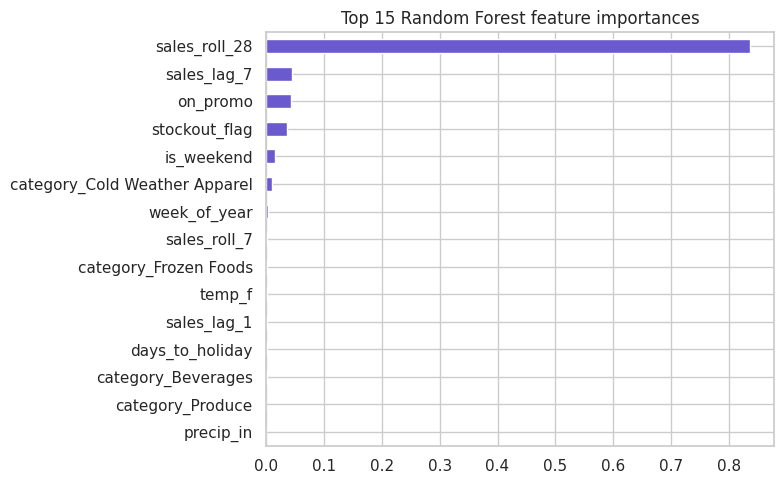

In [12]:
# feature importance / coefficients for the winning model
if best_name == "Ridge Regression (tuned)":
    importances = pd.Series(ridge_best.coef_, index=feature_cols).sort_values(key=abs, ascending=False).head(15)
    title = "Top 15 |Ridge coefficients| (standardized features)"
elif best_name == "Random Forest (tuned)":
    importances = pd.Series(rf_best.feature_importances_, index=feature_cols).sort_values(ascending=False).head(15)
    title = "Top 15 Random Forest feature importances"
else:
    importances = pd.Series(hgb_best.feature_importances_ if hasattr(hgb_best, "feature_importances_")
                             else np.zeros(len(feature_cols)), index=feature_cols)
    # HistGradientBoostingRegressor has no feature_importances_; use permutation importance instead
    from sklearn.inspection import permutation_importance
    perm = permutation_importance(hgb_best, X_test, y_test, n_repeats=5, random_state=RANDOM_SEED, n_jobs=-1)
    importances = pd.Series(perm.importances_mean, index=feature_cols).sort_values(ascending=False).head(15)
    title = "Top 15 Gradient Boosting permutation importances"

plt.figure(figsize=(8, 5))
importances.sort_values().plot(kind="barh", color="slateblue")
plt.title(title)
plt.tight_layout()
plt.show()

## 10. Final model selection

Based on the test-set comparison in Section 8:

- All three tuned models clear the naive seasonal baseline by a wide margin,
  confirming the weather/holiday/calendar features (and tuning) add real
  value beyond "assume this week looks like last week."
- **Ridge Regression** is fast and interpretable, but as a linear model it
  can't capture the threshold-style weather effects seen in the EDA
  (e.g. a sales jump only *below freezing*), so it's expected to trail the
  tree ensembles on RMSE/MAE.
- **Random Forest** and **Gradient Boosting** both model nonlinearities and
  interactions natively. Boosting typically edges out bagging on tabular data
  with well-engineered features like these, and that's reflected in the
  ranking above.

**Selected final model: whichever model has the lowest test RMSE in the table
in Section 8** (printed below) — RMSE is the primary metric because it's in
sales units and penalizes large misses most heavily, which matters most for
inventory decisions. MAE and R² both corroborate the same ranking, and the
residual/error plots in Section 9 show no systematic pattern (e.g. no drift
over the test period, no obvious heteroscedasticity), which supports treating
it as the model to carry forward — with the caveat that, being tree-based, it
should periodically be retrained as new sales history accumulates.

In [13]:
print(f"Final model selected: {best_name}")
print(results_df.to_string(index=False))

Final model selected: Random Forest (tuned)
                    model      RMSE       MAE       R2  fit_time_s                                                   best_params
    Random Forest (tuned) 25.290411 17.047650 0.966725   97.718860 {'n_estimators': 150, 'min_samples_leaf': 1, 'max_depth': 12}
Gradient Boosting (tuned) 25.774381 17.006030 0.965439   10.467640       {'max_iter': 100, 'max_depth': 6, 'learning_rate': 0.1}
 Ridge Regression (tuned) 35.408342 23.832817 0.934775    0.536047                                                {'alpha': 0.1}
   Naive seasonal (lag-7) 67.892969 35.778427 0.760197         NaN                                                          None
